Piriyadharshini N
24BAD086
Exp 7
Silhouette Score: 0.5546571631111091


C:\Users\piriyadharshini\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\piriyadharshini\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\piriyadharshini\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\piriyadharshini\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans 

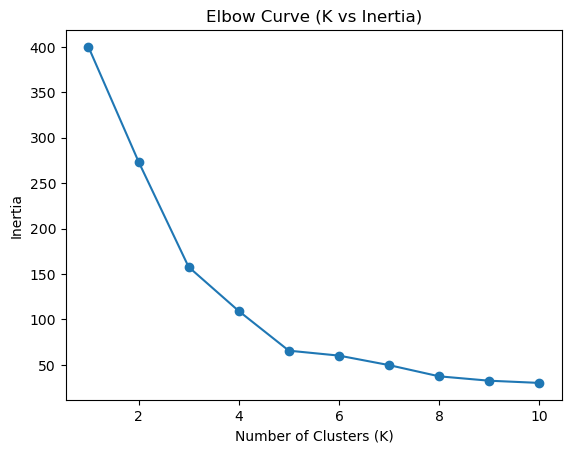

C:\Users\piriyadharshini\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


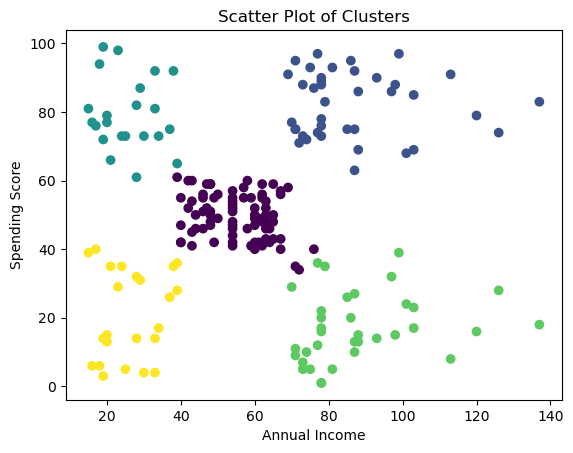

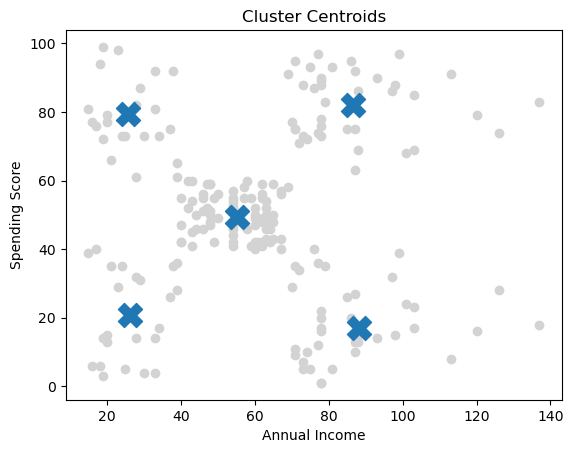

In [11]:
print("Piriyadharshini N\n24BAD086\nExp 7")

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

df = pd.read_csv("Mall_Customers.csv")

X = df[['Annual Income (k$)','Spending Score (1-100)']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertia = []
K = range(1,11)

score = silhouette_score(X_scaled, labels)
print("Silhouette Score:", score)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure()
plt.plot(K, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Curve (K vs Inertia)")
plt.show()

kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(X_scaled)

df['Cluster'] = labels

centroids = scaler.inverse_transform(kmeans.cluster_centers_)

plt.figure()
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], c=labels)
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Scatter Plot of Clusters")
plt.show()

plt.figure()
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], c='lightgray')
plt.scatter(centroids[:,0], centroids[:,1], s=300, marker='X')
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Cluster Centroids")
plt.show()

Piriyadharshini N
24BAD086
Exp 7


C:\Users\piriyadharshini\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


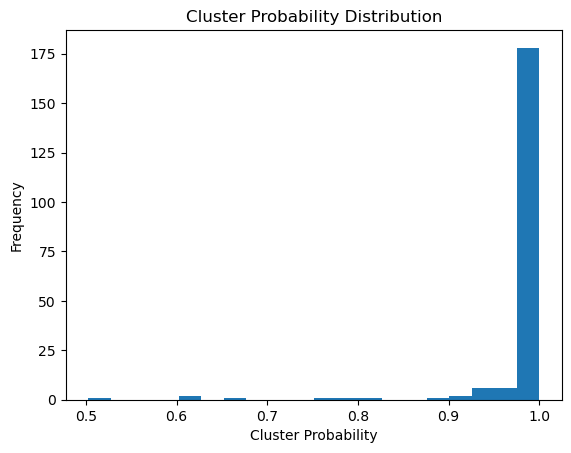

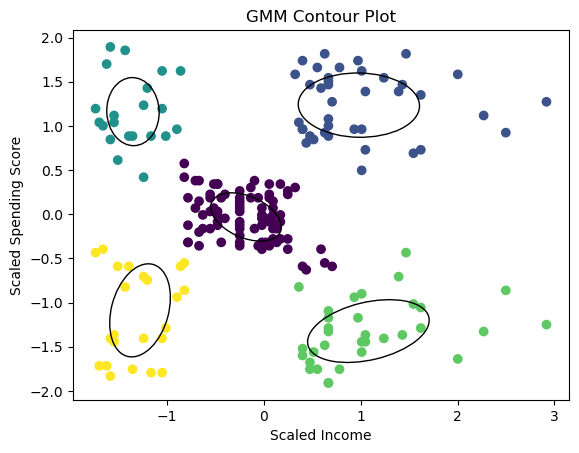

C:\Users\piriyadharshini\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


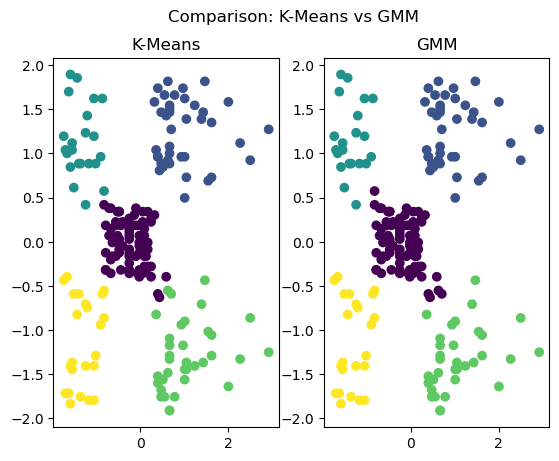

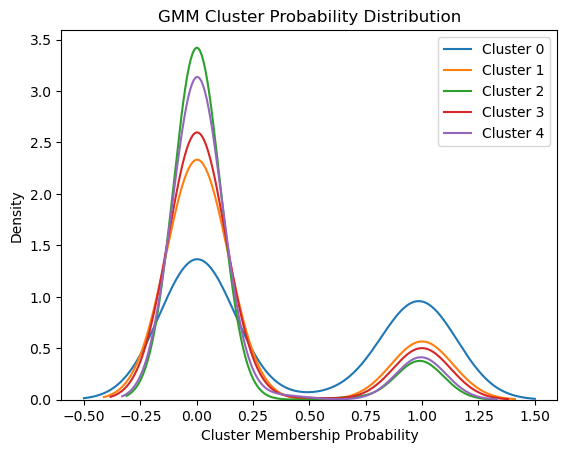

In [10]:
print("Piriyadharshini N\n24BAD086\nExp 7")

import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from matplotlib.patches import Ellipse

df = pd.read_csv("Mall_Customers.csv")

X = df[['Annual Income (k$)','Spending Score (1-100)']]

#Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#training gmm model
gmm = GaussianMixture(n_components=5, random_state=42)
gmm.fit(X_scaled)

labels_gmm = gmm.predict(X_scaled)
prob = gmm.predict_proba(X_scaled)

plt.figure()
plt.hist(prob.max(axis=1), bins=20)
plt.xlabel("Cluster Probability")
plt.ylabel("Frequency")
plt.title("Cluster Probability Distribution")
plt.show()

plt.figure()
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=labels_gmm)

for mean, cov in zip(gmm.means_, gmm.covariances_):
    v, w = np.linalg.eigh(cov)
    v = 2 * np.sqrt(v)
    u = w[0] / np.linalg.norm(w[0])
    angle = np.degrees(np.arctan2(u[1], u[0]))
    ell = Ellipse(mean, v[0], v[1], angle=angle, edgecolor='black', facecolor='none')
    plt.gca().add_patch(ell)

plt.title("GMM Contour Plot")
plt.xlabel("Scaled Income")
plt.ylabel("Scaled Spending Score")
plt.show()

kmeans = KMeans(n_clusters=5, random_state=42)
labels_km = kmeans.fit_predict(X_scaled)

plt.figure()

plt.subplot(1,2,1)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=labels_km)
plt.title("K-Means")

plt.subplot(1,2,2)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=labels_gmm)
plt.title("GMM")

plt.suptitle("Comparison: K-Means vs GMM")
plt.show()

prob = gmm.predict_proba(X_scaled)

plt.figure()

for i in range(prob.shape[1]):
    sns.kdeplot(prob[:, i], label="Cluster " + str(i))

plt.xlabel("Cluster Membership Probability")
plt.ylabel("Density")
plt.title("GMM Cluster Probability Distribution")
plt.legend()
plt.show()